Atividade 3

Luis Ernani Viniski

Leonardo Barbosa dos Santos

Gabriel Ximenes Bezerra Carrazzoni

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [ ]:
df = pd.read_csv('/content/Mall_Customers.csv')

Entendendo o Dataset

In [ ]:
print(df.head())

   CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None


In [ ]:
print(df.describe())

       CustomerID         Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000  200.000000          200.000000              200.000000
mean   100.500000   38.850000           60.560000               50.200000
std     57.879185   13.969007           26.264721               25.823522
min      1.000000   18.000000           15.000000                1.000000
25%     50.750000   28.750000           41.500000               34.750000
50%    100.500000   36.000000           61.500000               50.000000
75%    150.250000   49.000000           78.000000               73.000000
max    200.000000   70.000000          137.000000               99.000000


In [ ]:
#convertendo o gênero em binario
df['Genre'] = df['Genre'].map({'Male': 0, 'Female': 1})

In [ ]:
# Selecionar as colunas para clusterização
X = df[['Genre', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']]

In [ ]:
#Padronizando os dados para garantir que todas as variáveis contribuam igualmente para a distância calculada pelo K-Means
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

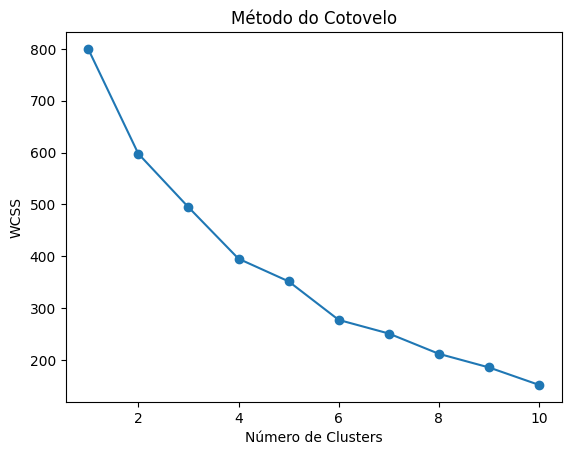

In [ ]:
#determinando o número ideal de cluster, utilizando o método de cotovelo
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss, marker='o')
plt.title('Método do Cotovelo')
plt.xlabel('Número de Clusters')
plt.ylabel('WCSS')
plt.show()

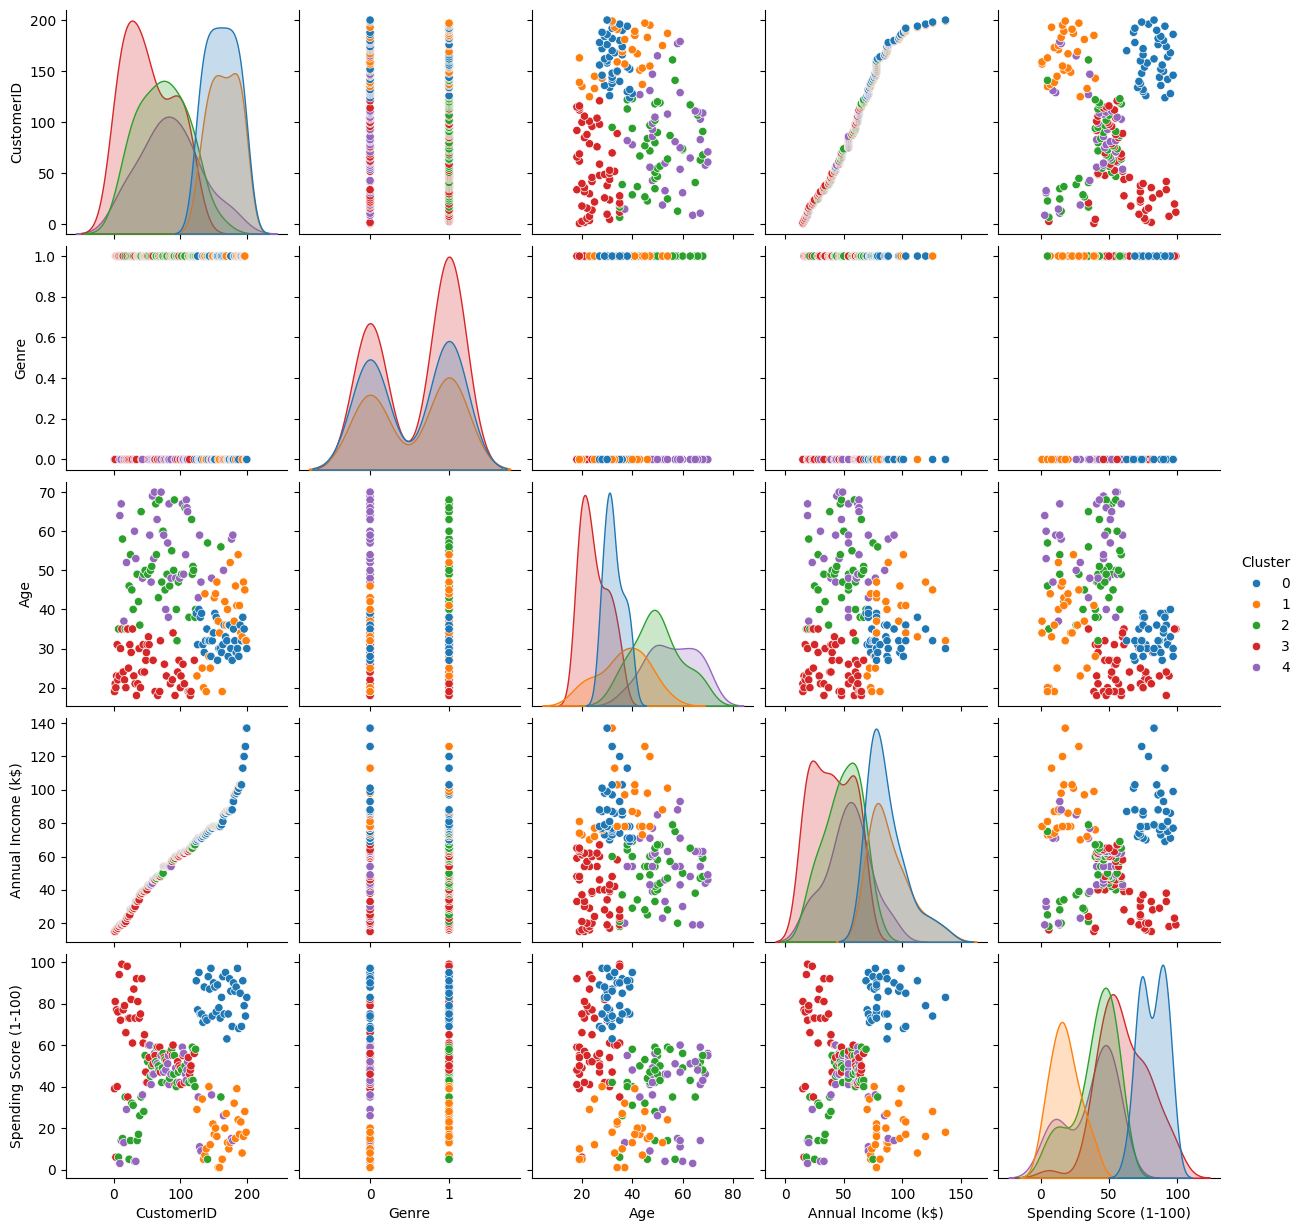

In [ ]:
# Aplicar K-Means com 5 clusters (conforme análise do cotovelo)
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

# Visualizar os clusters
sns.pairplot(df, hue='Cluster', palette='tab10')
plt.show()

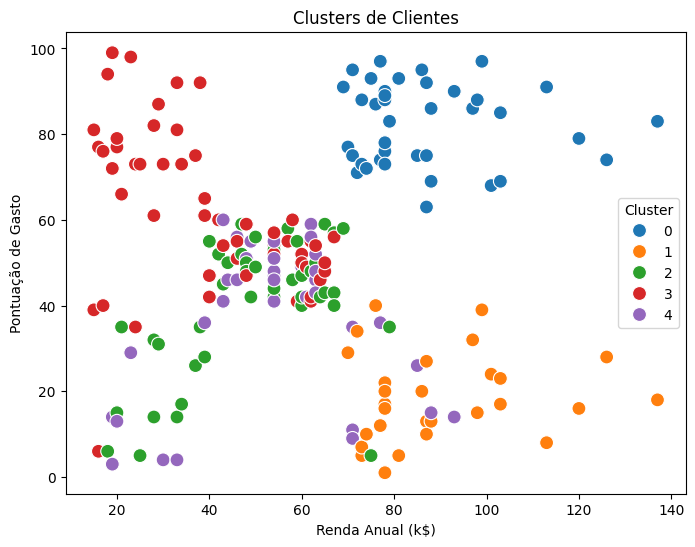

In [ ]:
# Gráfico de dispersão dos clusters
plt.figure(figsize=(8,6))
sns.scatterplot(x=df['Annual Income (k$)'], y=df['Spending Score (1-100)'], hue=df['Cluster'], palette='tab10', s=100)
plt.title('Clusters de Clientes')
plt.xlabel('Renda Anual (k$)')
plt.ylabel('Pontuação de Gasto')
plt.legend(title='Cluster')
plt.show()

In [ ]:
# Estatísticas descritivas por cluster
cluster_summary = df.groupby('Cluster').mean()
display(cluster_summary)

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,,,
0,162.000000,0.538462,32.692308,86.538462,82.128205
1,165.482759,0.551724,36.482759,89.517241,18.000000
2,73.651163,1.000000,49.813953,49.232558,40.069767
3,52.814815,0.592593,24.907407,39.722222,61.203704
4,84.685714,0.000000,55.714286,53.685714,36.771429


##**📊 Distribuição dos Clusters e sua Interpretação**
A análise identifica cinco clusters distintos com base em idade, renda e hábitos de consumo. Cada grupo apresenta características particulares, permitindo traçar estratégias mais eficazes para cada perfil de cliente.

**Cluster 0 (🔵 Azul) - Jovens de Alta Renda e Alto Consumo**

📈 Adultos Jovens | Alta Renda | Gastos Elevados

Média: 32 anos | Renda: 86.5k | Spending Score: 82.1

🔹 Grupo jovem, financeiramente bem posicionado e com alto potencial de consumo.

🔹 Possuem alto interesse por produtos premium e experiências exclusivas.

🔹 Estratégia: Fidelização, campanhas para produtos de alto valor e benefícios exclusivos.

**Cluster 1 (🟠 Laranja) - Clientes de Alta Renda, Mas Gastos Conservadores**

💰 Adultos de Meia-Idade | Alta Renda | Baixo Consumo

Média: 36 anos | Renda: 89.5k | Spending Score: 18.0

🔹 Profissionais de renda alta, mas que preferem gastar menos.

🔹 Possivelmente focam em investimentos e compras planejadas.

🔹 Estratégia: Produtos de alto valor agregado, ofertas para compras recorrentes e benefícios financeiros (cashback, descontos progressivos).


**Cluster 2 (🟢 Verde) - Pessoas de Meia-Idade com Renda Média e Consumo Moderado**

📊 Homens Predominantes | Meia-Idade | Renda Média | Gastos Equilibrados

Média: 49 anos | Renda: 49.2k | Spending Score: 40.1

🔹 Consumidores mais racionais, com gastos controlados e planejamento financeiro.

🔹 Possivelmente clientes leais a marcas que oferecem bom custo-benefício.

🔹 Estratégia: Programas de fidelização, atendimento personalizado e produtos duráveis.

**Cluster 3 (🔴 Vermelho) - Jovens de Renda Baixa, Mas Alto Consumo**

🛍️ Jovens Adultos | Baixa Renda | Gastam Muito

Média: 24 anos | Renda: 39.7k | Spending Score: 61.2

🔹 Grupo mais propenso a compras por impulso e atraído por tendências.

🔹 Alto engajamento em redes sociais e compras online.

🔹 Estratégia: Marketing digital agressivo, campanhas com influenciadores e promoções relâmpago.

**Cluster 4 (🟣 Roxo) - Clientes Mais Velhos com Renda Média e Gastos Reduzidos**

👨‍🦳 Maioria Masculina | Idade Elevada | Renda Média | Baixo Consumo

Média: 55 anos | Renda: 53.7k | Spending Score: 36.7

🔹 Grupo mais velho e conservador nos gastos, priorizando necessidades essenciais.

🔹 Possível perfil de aposentados ou profissionais em transição de carreira.

🔹 Estratégia: Produtos práticos e de alta durabilidade, promoções para fidelização e opções de parcelamento acessíveis.
